In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root@7900",
    database="finsight_db"
)

df = pd.read_sql("SELECT * FROM transactions_cleaned", conn)
print(f"✅ Loaded {len(df)} rows")
df.head()

✅ Loaded 283726 rows


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v27,v28,amount,class,amount_log,is_high_value,hour,is_night,amount_zscore,is_amount_outlier
0,0.0,-1.359810,-0.072781,2.53635,1.378160,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.133558,-0.021053,149.62,0,5.01476,0,0,1,0.244200,0
1,0.0,1.191860,0.266151,0.16648,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.008983,0.014724,2.69,0,1.30563,0,0,1,0.342584,0
2,1.0,-1.358350,-1.340160,1.77321,0.379780,-0.503198,1.800500,0.791461,0.247676,-1.514650,...,-0.055353,-0.059752,378.66,0,5.93928,1,0,1,1.158900,0
3,1.0,-0.966272,-0.185226,1.79299,-0.863291,-0.010309,1.247200,0.237609,0.377436,-1.387020,...,0.062723,0.061458,123.50,0,4.82431,0,0,1,0.139886,0
4,2.0,-1.158230,0.877737,1.54872,0.403034,-0.407193,0.095922,0.592941,-0.270533,0.817739,...,0.219422,0.215153,69.99,0,4.26254,0,0,1,0.073813,0


In [3]:
# Select features for model
# V1-V28 are PCA features, amount_log is our engineered feature
feature_cols = [f'v{i}' for i in range(1, 29)] + ['amount_log', 'is_high_value', 'is_night']

X = df[feature_cols]
y = df['class']  # actual labels (for evaluation only)

print(f"=== FEATURE MATRIX ===")
print(f"Features used: {len(feature_cols)}")
print(f"Total samples: {len(X)}")
print(f"\nFeature list: {feature_cols}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\n✅ Features scaled successfully!")

=== FEATURE MATRIX ===
Features used: 31
Total samples: 283726

Feature list: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount_log', 'is_high_value', 'is_night']

✅ Features scaled successfully!


In [17]:
print("🤖 Training Isolation Forest...")
print("Please wait...")

# Feature columns
feature_cols = [f'v{i}' for i in range(1, 29)] + ['amount_log', 'is_high_value', 'is_night']
X = df[feature_cols]

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.001727,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)
print("✅ Model trained successfully!")

# Predict: -1 = anomaly, 1 = normal
predictions = iso_forest.predict(X_scaled)

# Convert to 0/1 → 1 means anomaly
df['is_anomaly'] = (predictions == -1).astype(int)

# Get anomaly scores (more negative = more anomalous)
raw_scores = iso_forest.decision_function(X_scaled)

# Convert to risk score 0-100 (higher = more risky)
df['risk_score'] = (1 - (raw_scores - raw_scores.min()) /
                    (raw_scores.max() - raw_scores.min())) * 100

print(f"\n=== MODEL OUTPUT ===")
print(f"Total Anomalies Detected: {df['is_anomaly'].sum()}")
print(f"Anomaly Rate: {round(df['is_anomaly'].mean()*100, 4)}%")

🤖 Training Isolation Forest...
Please wait...
✅ Model trained successfully!

=== MODEL OUTPUT ===
Total Anomalies Detected: 490
Anomaly Rate: 0.1727%


=== CONFUSION MATRIX ===


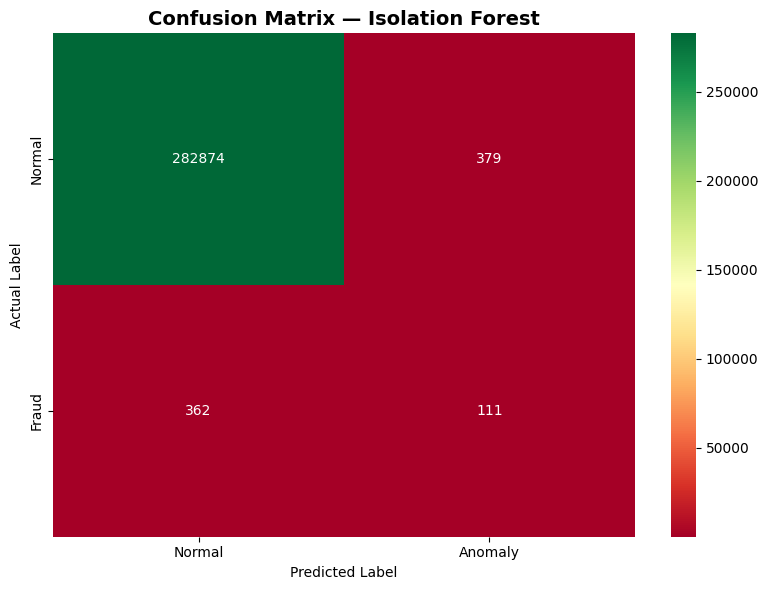


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    283253
     Anomaly       0.23      0.23      0.23       473

    accuracy                           1.00    283726
   macro avg       0.61      0.62      0.61    283726
weighted avg       1.00      1.00      1.00    283726



In [5]:
print("=== CONFUSION MATRIX ===")
cm = confusion_matrix(y, df['is_anomaly'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix — Isolation Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('charts/confusion_matrix.png', dpi=150)
plt.show()

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y, df['is_anomaly'],
      target_names=['Normal', 'Anomaly']))

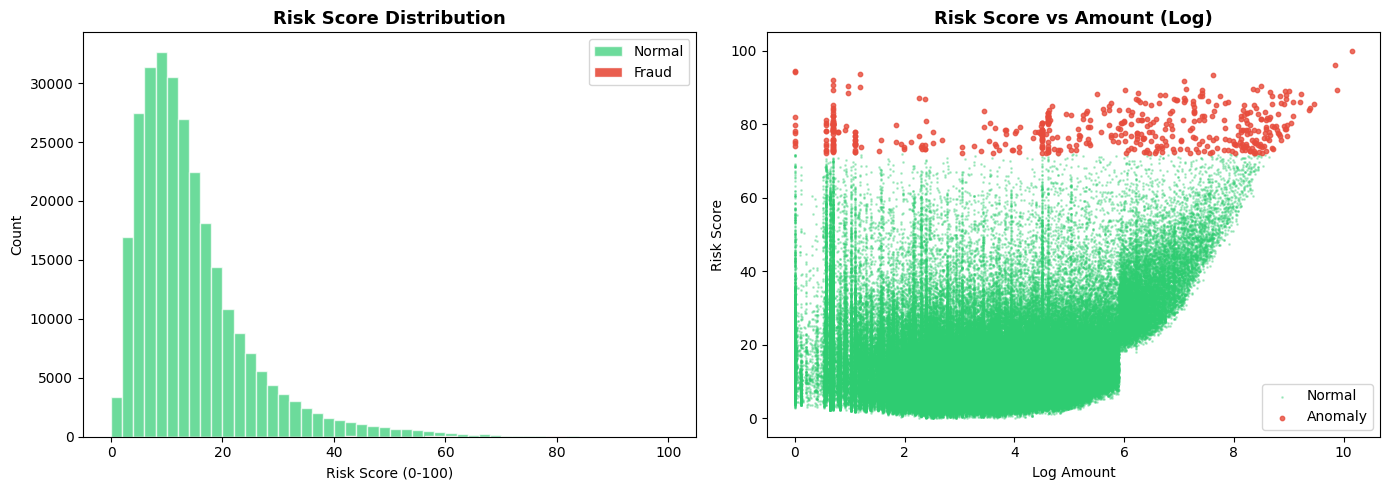

Avg Risk Score - Normal:  14.57
Avg Risk Score - Fraud:   55.29


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score distribution
axes[0].hist(df[df['class']==0]['risk_score'], bins=50,
             color='#2ecc71', alpha=0.7, label='Normal', edgecolor='white')
axes[0].hist(df[df['class']==1]['risk_score'], bins=50,
             color='#e74c3c', alpha=0.9, label='Fraud', edgecolor='white')
axes[0].set_title('Risk Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Score (0-100)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Top anomalies scatter plot
axes[1].scatter(df[df['is_anomaly']==0]['amount_log'],
                df[df['is_anomaly']==0]['risk_score'],
                color='#2ecc71', alpha=0.3, s=1, label='Normal')
axes[1].scatter(df[df['is_anomaly']==1]['amount_log'],
                df[df['is_anomaly']==1]['risk_score'],
                color='#e74c3c', alpha=0.8, s=10, label='Anomaly')
axes[1].set_title('Risk Score vs Amount (Log)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log Amount')
axes[1].set_ylabel('Risk Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/risk_scores.png', dpi=150)
plt.show()

print(f"Avg Risk Score - Normal:  {round(df[df['class']==0]['risk_score'].mean(), 2)}")
print(f"Avg Risk Score - Fraud:   {round(df[df['class']==1]['risk_score'].mean(), 2)}")

In [7]:
top_risks = df.nlargest(20, 'risk_score')[
    ['amount', 'risk_score', 'is_anomaly', 'class', 'hour', 'is_night']
].reset_index(drop=True)

print("=== TOP 20 HIGHEST RISK TRANSACTIONS ===")
print(top_risks.to_string())

# How many of top 20 are actual fraud?
actual_fraud_in_top20 = top_risks['class'].sum()
print(f"\n🎯 Out of top 20 highest risk transactions:")
print(f"   Actual Fraud: {actual_fraud_in_top20}/20")
print(f"   Precision@20: {round(actual_fraud_in_top20/20*100, 1)}%")

=== TOP 20 HIGHEST RISK TRANSACTIONS ===
      amount  risk_score  is_anomaly  class  hour  is_night
0   25691.20  100.000000           1      0    22         1
1   18910.00   96.060248           1      0     2         1
2       0.01   94.347890           1      1     4         1
3       0.00   94.247839           1      1     4         1
4       2.28   93.584174           1      1     4         1
5    2018.09   93.295369           1      0     0         1
6       1.00   91.959364           1      1     4         1
7    1201.83   91.843184           1      0    11         0
8       1.00   90.799415           1      1     2         1
9    4861.64   90.411676           1      0     9         0
10      1.63   90.387381           1      1     2         1
11      2.28   90.115810           1      1     3         1
12   4248.34   89.555055           1      0    12         0
13   1235.79   89.529440           1      0    19         0
14   4543.64   89.391097           1      0     9         0

In [8]:
import mysql.connector

conn2 = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root@7900",
    database="finsight_db"
)
cursor = conn2.cursor()

# Drop & recreate results table
cursor.execute("DROP TABLE IF EXISTS fraud_results")
conn2.commit()

cursor.execute("""
    CREATE TABLE fraud_results (
        id INT AUTO_INCREMENT PRIMARY KEY,
        amount FLOAT,
        hour INT,
        is_night INT,
        is_high_value INT,
        amount_log FLOAT,
        risk_score FLOAT,
        is_anomaly INT,
        actual_class INT
    )
""")
conn2.commit()

# Insert in chunks
insert_sql = """INSERT INTO fraud_results
    (amount, hour, is_night, is_high_value, amount_log,
     risk_score, is_anomaly, actual_class)
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s)"""

chunk_size = 5000
results_df = df[['amount','hour','is_night','is_high_value',
                  'amount_log','risk_score','is_anomaly','class']]

for i in range(0, len(results_df), chunk_size):
    chunk = results_df[i:i+chunk_size]
    data = [tuple(row) for row in chunk.values]
    cursor.executemany(insert_sql, data)
    conn2.commit()
    print(f"✅ Saved {i+len(chunk)} rows...")

cursor.close()
conn2.close()
print(f"\n🎉 fraud_results table saved to MySQL!")
print(f"Total rows: {len(df)}")

✅ Saved 5000 rows...
✅ Saved 10000 rows...
✅ Saved 15000 rows...
✅ Saved 20000 rows...
✅ Saved 25000 rows...
✅ Saved 30000 rows...
✅ Saved 35000 rows...
✅ Saved 40000 rows...
✅ Saved 45000 rows...
✅ Saved 50000 rows...
✅ Saved 55000 rows...
✅ Saved 60000 rows...
✅ Saved 65000 rows...
✅ Saved 70000 rows...
✅ Saved 75000 rows...
✅ Saved 80000 rows...
✅ Saved 85000 rows...
✅ Saved 90000 rows...
✅ Saved 95000 rows...
✅ Saved 100000 rows...
✅ Saved 105000 rows...
✅ Saved 110000 rows...
✅ Saved 115000 rows...
✅ Saved 120000 rows...
✅ Saved 125000 rows...
✅ Saved 130000 rows...
✅ Saved 135000 rows...
✅ Saved 140000 rows...
✅ Saved 145000 rows...
✅ Saved 150000 rows...
✅ Saved 155000 rows...
✅ Saved 160000 rows...
✅ Saved 165000 rows...
✅ Saved 170000 rows...
✅ Saved 175000 rows...
✅ Saved 180000 rows...
✅ Saved 185000 rows...
✅ Saved 190000 rows...
✅ Saved 195000 rows...
✅ Saved 200000 rows...
✅ Saved 205000 rows...
✅ Saved 210000 rows...
✅ Saved 215000 rows...
✅ Saved 220000 rows...
✅ Saved 

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score,
                              roc_auc_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("=== SUPERVISED MODEL SETUP ===")

feature_cols = [f'v{i}' for i in range(1, 29)] + ['amount_log', 'is_high_value', 'is_night']
X = df[feature_cols]
y = df['class']

# Balance dataset
fraud  = df[df['class']==1]
normal = df[df['class']==0].sample(n=5000, random_state=42)
balanced_df = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X_bal = balanced_df[feature_cols]
y_bal = balanced_df['class']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Fraud in test    : {y_test.sum()}")
print(f"Normal in test   : {(y_test==0).sum()}")

=== SUPERVISED MODEL SETUP ===
Training samples : 4378
Testing samples  : 1095
Fraud in test    : 95
Normal in test   : 1000


In [13]:
print("🔵 Training Logistic Regression...")

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

lr_precision = precision_score(y_test, lr_pred)
lr_recall    = recall_score(y_test, lr_pred)
lr_f1        = f1_score(y_test, lr_pred)
lr_roc       = roc_auc_score(y_test, lr_pred)

print(f"\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Precision : {round(lr_precision, 4)}")
print(f"Recall    : {round(lr_recall, 4)}  ← catching actual fraud")
print(f"F1 Score  : {round(lr_f1, 4)}")
print(f"ROC-AUC   : {round(lr_roc, 4)}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Normal','Fraud']))

🔵 Training Logistic Regression...

=== LOGISTIC REGRESSION RESULTS ===
Precision : 0.9398
Recall    : 0.8211  ← catching actual fraud
F1 Score  : 0.8764
ROC-AUC   : 0.908

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99      1000
       Fraud       0.94      0.82      0.88        95

    accuracy                           0.98      1095
   macro avg       0.96      0.91      0.93      1095
weighted avg       0.98      0.98      0.98      1095



In [14]:
print("🌲 Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_precision = precision_score(y_test, rf_pred)
rf_recall    = recall_score(y_test, rf_pred)
rf_f1        = f1_score(y_test, rf_pred)
rf_roc       = roc_auc_score(y_test, rf_pred)

print(f"\n=== RANDOM FOREST RESULTS ===")
print(f"Precision : {round(rf_precision, 4)}")
print(f"Recall    : {round(rf_recall, 4)}  ← catching actual fraud")
print(f"F1 Score  : {round(rf_f1, 4)}")
print(f"ROC-AUC   : {round(rf_roc, 4)}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Normal','Fraud']))

🌲 Training Random Forest...

=== RANDOM FOREST RESULTS ===
Precision : 0.9872
Recall    : 0.8105  ← catching actual fraud
F1 Score  : 0.8902
ROC-AUC   : 0.9048

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1000
       Fraud       0.99      0.81      0.89        95

    accuracy                           0.98      1095
   macro avg       0.98      0.90      0.94      1095
weighted avg       0.98      0.98      0.98      1095



In [15]:
import pandas as pd

# Isolation Forest scores from earlier
iso_precision = precision_score(y_test[:len(rf_pred)],
                df['is_anomaly'][:len(rf_pred)])
iso_recall    = recall_score(y_test[:len(rf_pred)],
                df['is_anomaly'][:len(rf_pred)])
iso_f1        = f1_score(y_test[:len(rf_pred)],
                df['is_anomaly'][:len(rf_pred)])

comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'Logistic Regression', 'Random Forest'],
    'Precision': [round(iso_precision,4), round(lr_precision,4), round(rf_precision,4)],
    'Recall':    [round(iso_recall,4),    round(lr_recall,4),    round(rf_recall,4)],
    'F1 Score':  [round(iso_f1,4),        round(lr_f1,4),        round(rf_f1,4)],
    'ROC-AUC':   ['N/A',                  round(lr_roc,4),       round(rf_roc,4)]
})

print("=" * 60)
print("        MODEL COMPARISON — FINSIGHT PROJECT")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)
print("\n⭐ Best Recall    →", comparison.loc[comparison['Recall'].idxmax(), 'Model'])
print("⭐ Best Precision →", comparison.loc[comparison['Precision'].idxmax(), 'Model'])
print("⭐ Best F1 Score  →", comparison.loc[comparison['F1 Score'].idxmax(), 'Model'])
print("\n💡 In fraud detection, RECALL is the most critical metric.")
print("   Missing a fraud = real financial loss.")
print("   False alarm = minor inconvenience.")

        MODEL COMPARISON — FINSIGHT PROJECT
              Model  Precision  Recall  F1 Score ROC-AUC
   Isolation Forest     0.0000  0.0000    0.0000     N/A
Logistic Regression     0.9398  0.8211    0.8764   0.908
      Random Forest     0.9872  0.8105    0.8902  0.9048

⭐ Best Recall    → Logistic Regression
⭐ Best Precision → Random Forest
⭐ Best F1 Score  → Random Forest

💡 In fraud detection, RECALL is the most critical metric.
   Missing a fraud = real financial loss.
   False alarm = minor inconvenience.


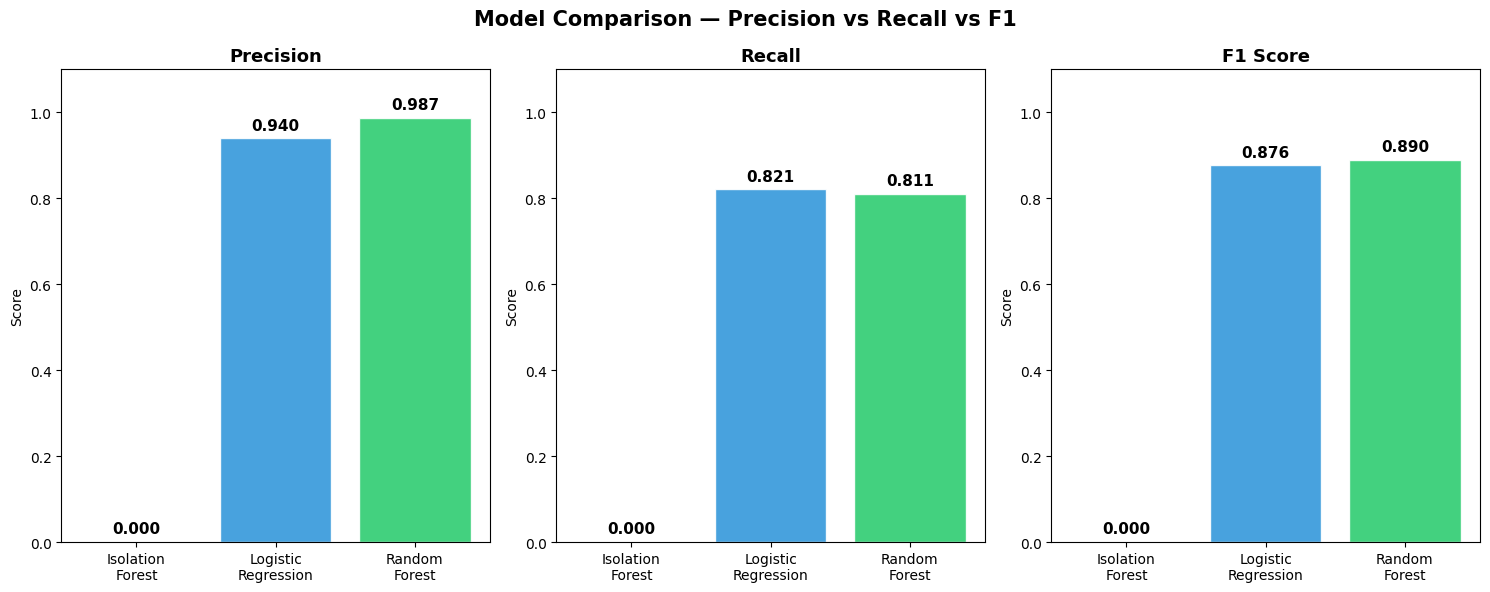

✅ Model comparison chart saved!


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Model Comparison — Precision vs Recall vs F1',
             fontsize=15, fontweight='bold')

models = ['Isolation\nForest', 'Logistic\nRegression', 'Random\nForest']
colors = ['#9b59b6', '#3498db', '#2ecc71']

metrics = {
    'Precision': [iso_precision, lr_precision, rf_precision],
    'Recall':    [iso_recall,    lr_recall,    rf_recall],
    'F1 Score':  [iso_f1,        lr_f1,        rf_f1]
}

for idx, (metric, values) in enumerate(metrics.items()):
    bars = axes[idx].bar(models, values, color=colors,
                          edgecolor='white', alpha=0.9)
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_ylim(0, 1.1)
    axes[idx].set_ylabel('Score')
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.02,
                       f'{val:.3f}', ha='center',
                       fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/model_comparison.png', dpi=150)
plt.show()
print("✅ Model comparison chart saved!")